
# Target-Event-Agent Networks (TEA Nets) Tutorial
This tutorial will guide you through the process of using the Target-Event-Agent (TEA) network framework to analyze textual data. TEA networks provide a unique approach to narrative analysis by focusing on the actors (Agent), actions (Event), and consequences (Target) portrayed in texts, constructing a multilayer semantic-syntactic network.

The TEA framework, available at https://github.com/MassimoStel/TEA_Networks.git, helps uncover narratives by examining actors (Agent), actions (Event), and consequences (Target) in text.

For additional guidance, you can refer to the official TEA library documentation:

[Starting Guide.ipynb](https://github.com/MassimoStel/TEA_Networks/blob/main/Docs%20%26%20Guides/Starting%20Guide.ipynb)

[Analyzing TEA.ipynb](https://github.com/MassimoStel/TEA_Networks/blob/main/Docs%20%26%20Guides/Analyzing%20TEA.ipynb)


## 1. Introduction to TEA Nets.
TEA Nets are a framework designed to analyze narratives core components: actors, actions, and consequences. These semantic/syntactic multilayer networks consist of three primary layers:

* Subjects/Actors (Agent): The entities performing actions.
* Verbs/Consequences (Event): The verbs connecting subjects to objects, often indicating consequences.
* Objects/Actions (Target): The actions being performed.

## 2. Setting Up Your Environment
Before we begin, ensure you have the necessary libraries installed.

### 2.1. Install `teanets` library

In [1]:
import sys
import os
sys.path.insert(0, os.path.abspath('..'))
# !pip install -q git+https://github.com/MassimoStel/TEA_Networks.git

### 2.2. Import necessary modules

In [2]:
import teanets as tea
import teanets.analytics

## 3. Basic example

As a minimal example, we will process the sentence:  
> "Alex and Ben care for animals and love hiking through national parks. However, they dislike shopping malls because they are overwhelming and chaotic."

We will load the text, extract the SVOs and plot the TEA graph.

In [3]:
text = """Alex and Ben care for animals and love hiking through national parks. However, they dislike shopping malls because they are overwhelming and chaotic."""

In [8]:
svo = tea.extract_svos_from_text(text)

Inference: 100%|██████████| 1/1 [00:00<00:00, 81.73it/s]


In [5]:
display(svo)

,Node 1,TEA,Node 2,TEA2,Hypergraph,Semantic-Syntactic,svo_id,passive_approx,is_passive
0,alex,Agent,care,Event,"[[('alex', []), ('ben', [])], ['care'], [('for...",0,0,0,0
1,ben,Agent,care,Event,"[[('alex', []), ('ben', [])], ['care'], [('for...",0,0,0,0
2,care,Event,for animal,Target,"[[('alex', []), ('ben', [])], ['care'], [('for...",0,0,0,0
3,alex,Agent,ben,Agent,"[[('alex', []), ('ben', [])], ['care'], [('for...",0,0,0,0
4,alex,Agent,love hike,Event,"[[('alex', []), ('ben', [])], ['love hike'], [...",0,1,0,0
5,ben,Agent,love hike,Event,"[[('alex', []), ('ben', [])], ['love hike'], [...",0,1,0,0
6,love hike,Event,through national park,Target,"[[('alex', []), ('ben', [])], ['love hike'], [...",0,1,0,0
7,alex,Agent,ben,Agent,"[[('alex', []), ('ben', [])], ['love hike'], [...",0,1,0,0
8,alex,Agent,however dislike,Event,"[[('alex', []), ('ben', [])], ['however dislik...",0,2,0,0
9,ben,Agent,however dislike,Event,"[[('alex', []), ('ben', [])], ['however dislik...",0,2,0,0


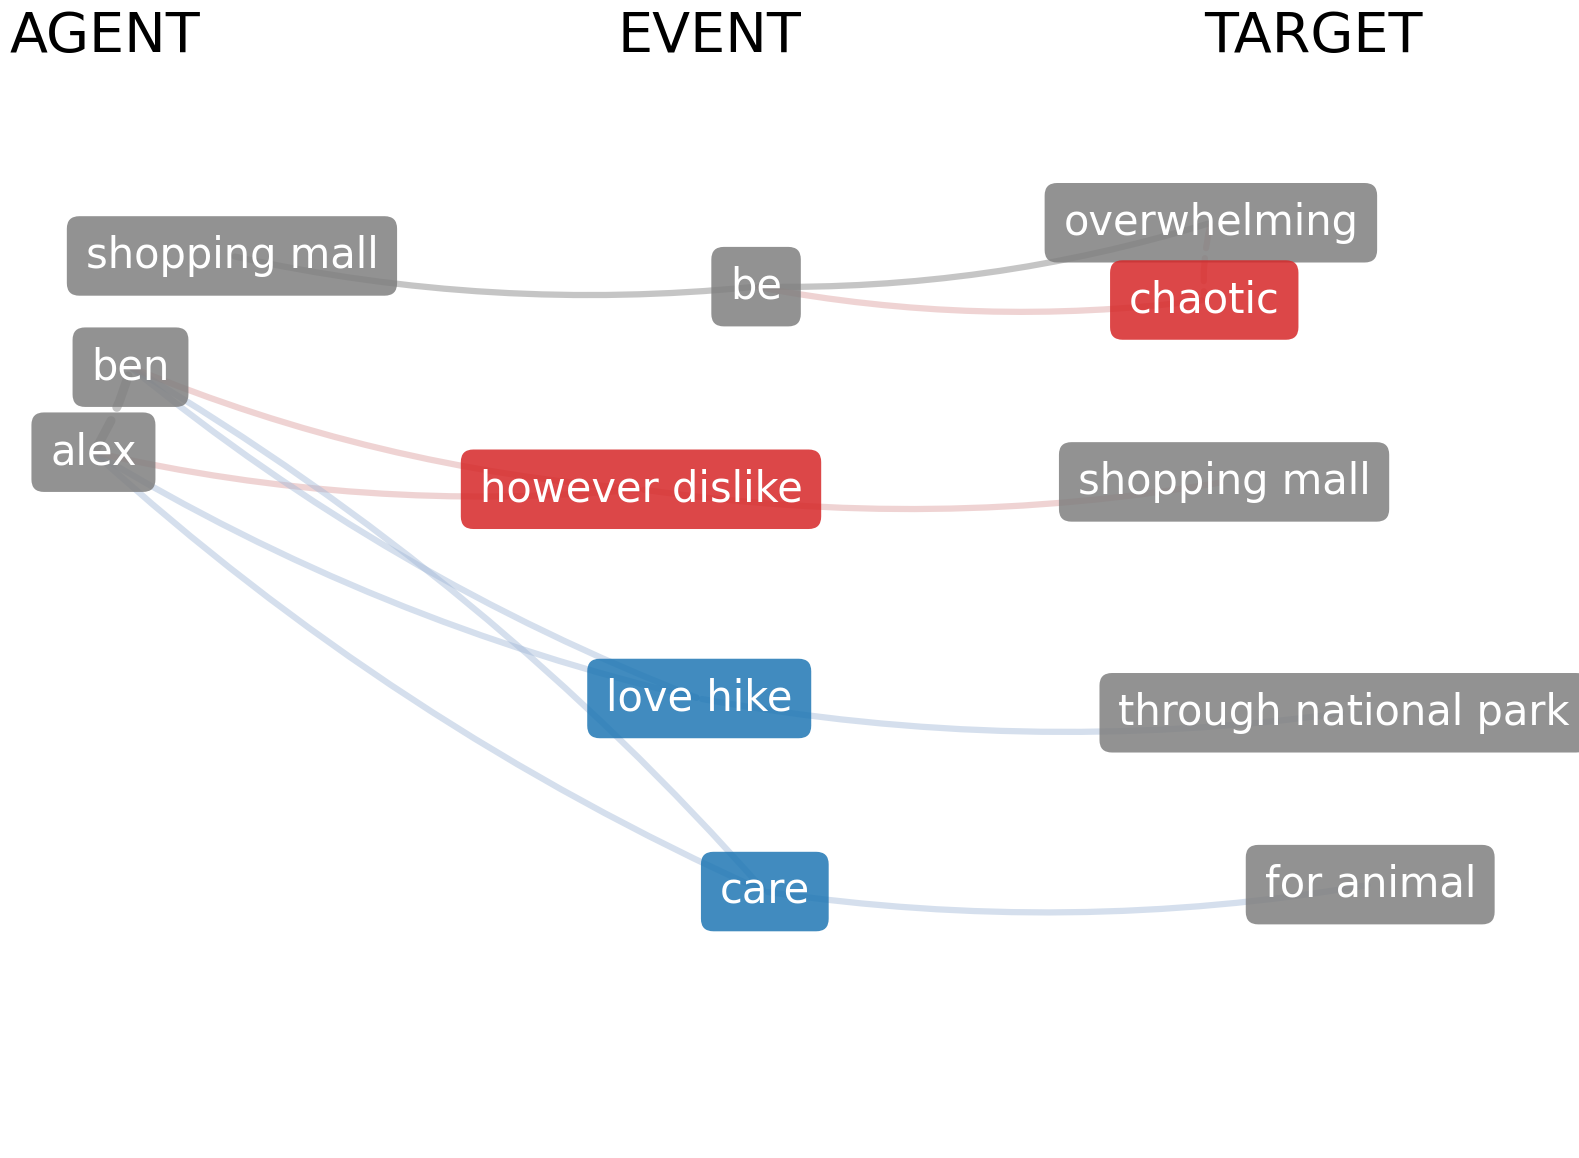

In [6]:
import teanets.teaplot as teaplot
teaplot.plot_svo_graph(
    svo,
    custom_font=30
)

Part-of-speech tagging is determined by an AI model (specifically, spaCy) analyzing each sentence in a text. Inter-layer connections are established using a rule-based approach applied to the syntactic parsing provided by spaCy. Intra-layer connections are semantic, established only if two words are synonyms (e.g., "father" and "dad").

Like in textual forma mentis networks, individual concepts are labeled as 'positive' (cyan), 'negative' (red), and 'neutral' (gray) according to **Vader** Sentiment Analysis. Inter-layer paths indicate 'target event agent' – i.e., which actions and which consequences were portrayed by specific agents in texts. While tools like EmoAtlas provide general results about the overall context of biased perceptions, TEA networks complement Textual Forma Mentis Networks (TFMNs) by offering a granular focus on actors, actions, and consequences.


## 4. Full Example / Recap
The following cell contains the complete code for extracting SVOs and plotting the TEA Network, all in one place.

Inference: 100%|██████████| 1/1 [00:00<00:00, 78.50it/s]


,Node 1,TEA,Node 2,TEA2,Hypergraph,Semantic-Syntactic,svo_id,passive_approx,is_passive
0,alex,Agent,care,Event,"[[('alex', []), ('ben', [])], ['care'], [('for...",0,0,0,0
1,ben,Agent,care,Event,"[[('alex', []), ('ben', [])], ['care'], [('for...",0,0,0,0
2,care,Event,for animal,Target,"[[('alex', []), ('ben', [])], ['care'], [('for...",0,0,0,0
3,alex,Agent,ben,Agent,"[[('alex', []), ('ben', [])], ['care'], [('for...",0,0,0,0
4,alex,Agent,love hike,Event,"[[('alex', []), ('ben', [])], ['love hike'], [...",0,1,0,0
5,ben,Agent,love hike,Event,"[[('alex', []), ('ben', [])], ['love hike'], [...",0,1,0,0
6,love hike,Event,through national park,Target,"[[('alex', []), ('ben', [])], ['love hike'], [...",0,1,0,0
7,alex,Agent,ben,Agent,"[[('alex', []), ('ben', [])], ['love hike'], [...",0,1,0,0
8,alex,Agent,however dislike,Event,"[[('alex', []), ('ben', [])], ['however dislik...",0,2,0,0
9,ben,Agent,however dislike,Event,"[[('alex', []), ('ben', [])], ['however dislik...",0,2,0,0


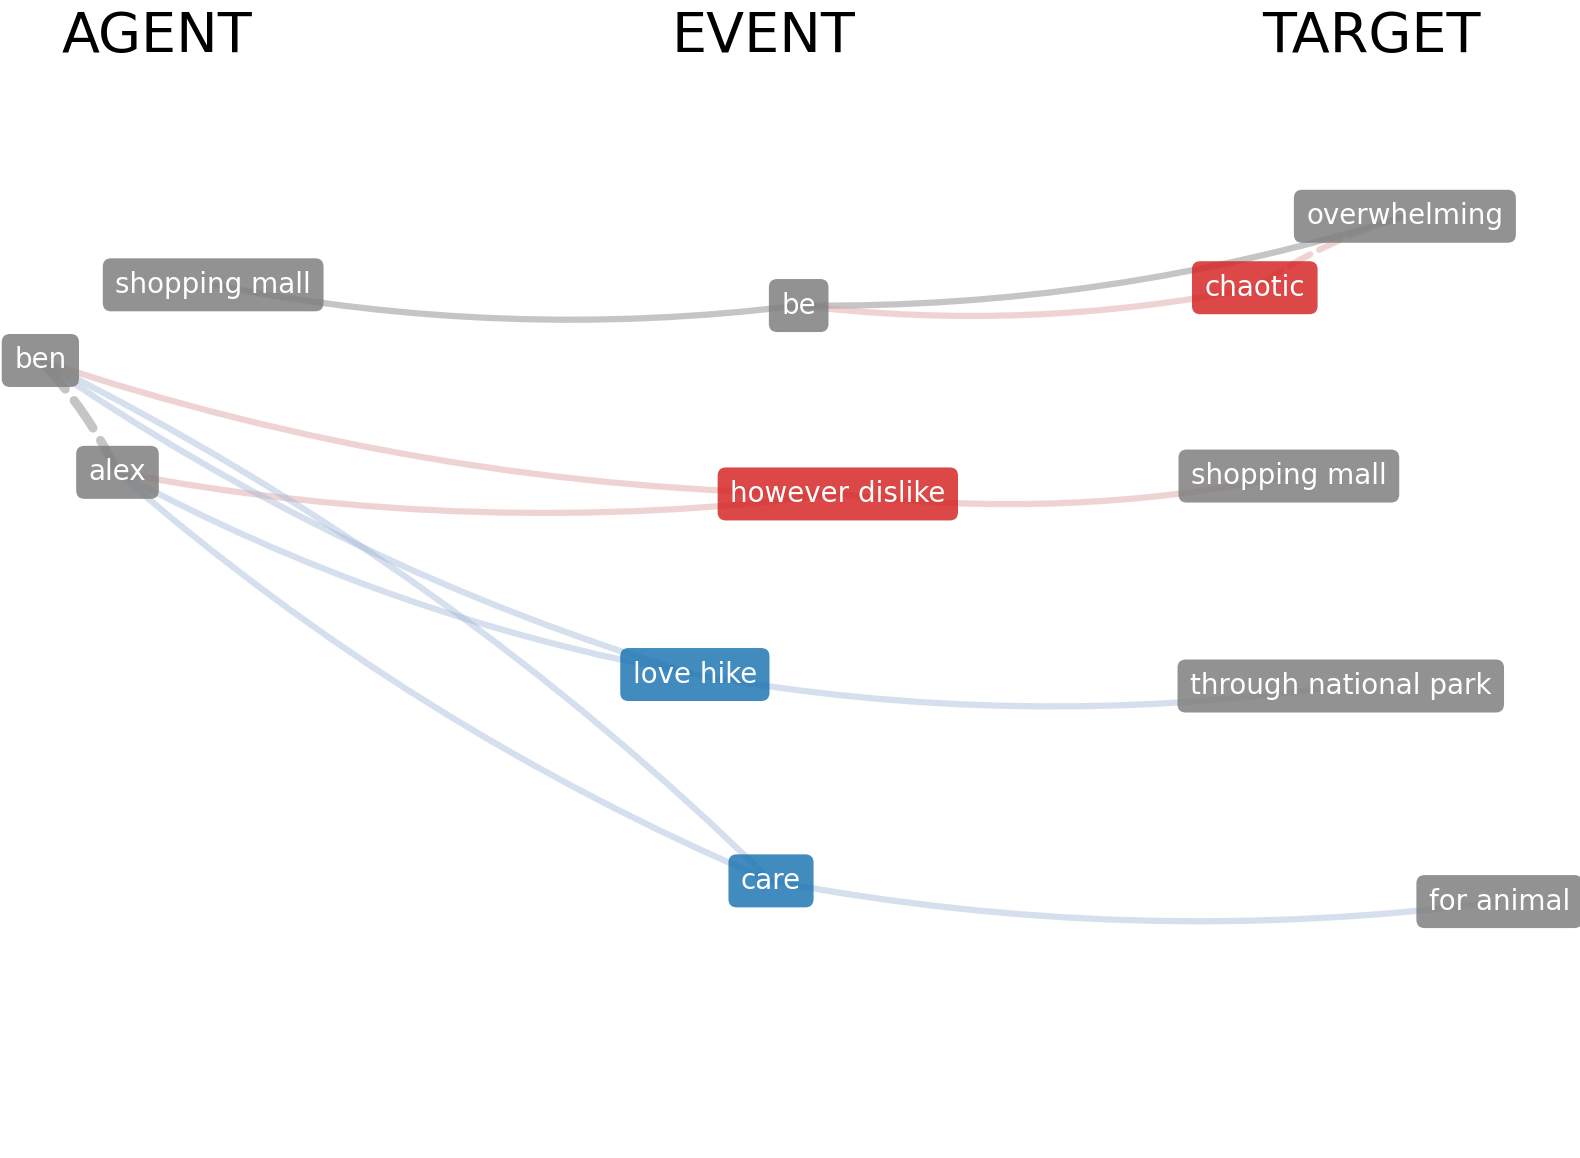

In [7]:
# 1. Load TEA Nets from this local repository
from pathlib import Path
import sys

repo_root = Path.cwd().resolve().parent
if str(repo_root) not in sys.path:
    sys.path.insert(0, str(repo_root))

# 1. Load necessary modules
import teanets as tea
import teanets.analytics

# 2. Extract SVO triplets from text
text = "Alex and Ben care for animals and love hiking through national parks. However, they dislike shopping malls because they are overwhelming and chaotic"
svo = tea.extract_svos_from_text(text)
display(svo)

# 3. Plot the TEA Net
import teanets.teaplot as teaplot
teaplot.plot_svo_graph(svo, custom_font=20)